In [1]:
import torch
import torch.nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

In [2]:
import sys
sys.path.append('/content/drive/My Drive/LLM/Notebooks')

In [3]:
from gpt_download import download_and_load_gpt2
from gpt2 import *
from utils import *

In [4]:
import json
import os
import urllib
import pprint
import tiktoken as tk
from functools import partial

In [5]:
x = torch.tensor([[1,2,3],
                  [4,5,6],
                  [7,8,9]])

y = x[[0,1,2], [0,1,2]]
y

tensor([1, 5, 9])

In [6]:
x = torch.tensor([[1, 2],
                  [3, 4]])

index = torch.tensor([[1, 0],
                      [0, 0]])

out = torch.gather(x, dim=0, index=index)
print(out)


tensor([[3, 2],
        [1, 2]])


In [7]:
out = torch.gather(x, dim=1, index=index)
print(out)

tensor([[2, 1],
        [3, 3]])


# **Data Preparation**

In [8]:
def download_and_load_file(file_path, url):
  if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
      text_data = response.read().decode("utf-8")
    with open(file_path, 'w', encoding='utf-8') as f:
      f.write(text_data)
  else:
    with open(file_path, 'r', encoding='utf-8') as f:
      text_data = f.read()
  with open(file_path, 'r') as f:
    data = json.load(f)
  return data

In [9]:
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch07/04_preference-tuning-with-dpo/instruction-data-with-preference.json"
file_path = '/content/drive/My Drive/LLM/Data/instruction-data-with-preference.json'

data = download_and_load_file(file_path, url)
print(f"Total entries: {len(data)}")

Total entries: 1100


In [10]:
pprint.pp(data[0])

{'instruction': 'Evaluate the following phrase by transforming it into the '
                'spelling given.',
 'input': 'freind --> friend',
 'output': 'The spelling of the given phrase "freind" is incorrect, the '
           'correct spelling is "friend".',
 'rejected': 'The spelling of the given phrase "freind" is flat out wrong, get '
             'it together, the correct spelling is "friend".',
 'chosen': 'The spelling of the given phrase "freind" is incorrect, the '
           'correct spelling is "friend".'}


In [11]:
pprint.pp(data[1000])

{'instruction': 'Name three forms of water.',
 'input': '',
 'output': 'The three forms of water are solid (ice), liquid (water), and gas '
           '(steam).',
 'rejected': 'Look, the three forms of water are solid (ice), liquid (water), '
             'and gas (steam), okay?',
 'chosen': 'The three forms of water are solid (ice), liquid (water), and gas '
           '(steam).'}


In [12]:
def format_entry(entry):
  instruction_text = (
      f"Below is the instruction that describes a task. Write an appropriate response to address the instruction. "
      f"\n\n### Instruction:\n{entry['instruction']}"
  )

  input_text = f"\n\n### Input:\n{entry['input']}" if entry['input'] else ""

  return instruction_text + input_text

In [13]:
print(format_entry(data[0]))

Below is the instruction that describes a task. Write an appropriate response to address the instruction. 

### Instruction:
Evaluate the following phrase by transforming it into the spelling given.

### Input:
freind --> friend


In [14]:
#split the dataset
def split_dataset(data, train_size, test_size):
  train_data = data[:int(len(data) * train_size)]
  test_data = data[int(len(data) * train_size):int(len(data) * (train_size + test_size))]
  val_data = data[int(len(data) * (train_size + test_size)):]

  return train_data, val_data, test_data

In [15]:
train_data, validation_data, test_data = split_dataset(data, 0.85, 0.1)

In [51]:
len(validation_data)

55

In [16]:
#build preference dataset
class PreferenceDataset(Dataset):
  def __init__(self, data, tokenizer):
    self.data = data
    self.prompt_lst, self.chosen_lst, self.rejected_lst = [], [], []

    for entry in data:
      prompt_text = format_entry(entry)
      encoded_prompt = tokenizer.encode(prompt_text)

      chosen_text = f"\n\n### Response:\n{entry['chosen']}"
      chosen_full_text = prompt_text + chosen_text
      encoded_chosen_full = tokenizer.encode(chosen_full_text)
      rejected_text = f"\n\n### Response:\n{entry['rejected']}"
      rejected_full_text = prompt_text + rejected_text
      encoded_rejected_full = tokenizer.encode(rejected_full_text)

      self.chosen_lst.append(encoded_chosen_full)
      self.rejected_lst.append(encoded_rejected_full)
      self.prompt_lst.append(encoded_prompt)

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    return self.prompt_lst[idx], self.chosen_lst[idx], self.rejected_lst[idx]

In [17]:
tokenizer = tk.get_encoding('gpt2')

In [18]:
train_dataset = PreferenceDataset(train_data, tokenizer)
validation_dataset = PreferenceDataset(validation_data, tokenizer)
test_dataset = PreferenceDataset(test_data, tokenizer)

In [19]:
print(f"Training Dataset size: {len(train_dataset)}")
print(f"Validation Dataset size: {len(validation_dataset)}")
print(f"Test Dataset size: {len(test_dataset)}")

Training Dataset size: 935
Validation Dataset size: 55
Test Dataset size: 110


In [20]:
#custom collate fn
def custom_collate_fn(batch, device='cpu', pad_token=50256, allowed_max_length=1024, mask_prompt=None):
  batch_op = {
      'chosen':[],
      'rejected':[],
      'chosen_mask':[],
      'rejected_mask':[]
  }

  batch_max_length = 0
  for _, chosen_encoded, rejected_encoded in batch:
    batch_max_length = batch_max_length if batch_max_length > len(chosen_encoded)+1 else len(chosen_encoded)+1
    batch_max_length = batch_max_length if batch_max_length > len(rejected_encoded)+1 else len(rejected_encoded)+1

  for prompt_tokens, chosen_tokens, rejected_tokens in batch:
    new_chosen_tokens = chosen_tokens.copy()
    new_rejected_tokens = rejected_tokens.copy()

    new_chosen_tokens += [pad_token]
    new_rejected_tokens += [pad_token]

    padded_chosen_tokens = new_chosen_tokens + [pad_token] * (batch_max_length - len(new_chosen_tokens))
    padded_rejected_tokens = new_rejected_tokens + [pad_token] * (batch_max_length - len(new_rejected_tokens))

    chosen_tensor = torch.tensor(padded_chosen_tokens)
    rejected_tensor = torch.tensor(padded_rejected_tokens)

    chosen_mask = torch.ones(len(padded_chosen_tokens)).bool()
    chosen_mask[len(new_chosen_tokens):] = False

    rejected_mask = torch.ones(len(padded_rejected_tokens)).bool()
    rejected_mask[len(new_rejected_tokens):] = False

    if mask_prompt is not None:
      chosen_mask[:len(prompt_tokens)+2] = False
      rejected_mask[:len(prompt_tokens)+2] = False

    batch_op['chosen'].append(chosen_tensor)
    batch_op['rejected'].append(rejected_tensor)
    batch_op['chosen_mask'].append(chosen_mask)
    batch_op['rejected_mask'].append(rejected_mask)

  for key in batch_op:
    batch_op[key] = torch.stack(batch_op[key]).to(device)

  if allowed_max_length is not None:
    for key in batch_op:
      batch_op[key][:,:allowed_max_length]

  return batch_op

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [22]:
customized_collate_fn = partial(custom_collate_fn, device=device, allowed_max_length=1024, mask_prompt=None)

In [23]:
torch.manual_seed(123)

num_workers = 0
batch_size = 8

train_loader = DataLoader(train_dataset, collate_fn=customized_collate_fn, batch_size=batch_size, num_workers=num_workers, shuffle=True, drop_last=True)
val_loader = DataLoader(validation_dataset, collate_fn=customized_collate_fn, batch_size=batch_size, num_workers=num_workers, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, collate_fn=customized_collate_fn, batch_size=batch_size, num_workers=num_workers, shuffle=False, drop_last=False)

In [24]:
for batch in train_loader:
  print(f"Batch keys: {batch.keys()}")
  print(f"{token_ids_to_text(batch['chosen'][0].unsqueeze(0), tokenizer)}")
  break

Batch keys: dict_keys(['chosen', 'rejected', 'chosen_mask', 'rejected_mask'])
Below is the instruction that describes a task. Write an appropriate response to address the instruction. 

### Instruction:
Rewrite the following sentence so that it is in active voice.

### Input:
The cake was baked by Sarah.

### Response:
Sarah baked the cake.<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>


# **Load fine-tuned model**

In [25]:
model_name = 'gpt2-medium (355M)'
model_save_path = '/content/drive/My Drive/LLM/Data/gpt2-medium-finetuned.pth'
BASE_CONFIG.update(model_configs[model_name])

In [26]:
BASE_CONFIG

{'vocab_size': 50257,
 'context_length': 1024,
 'drop_rate': 0.0,
 'qkv_bias': True,
 'emb_size': 1024,
 'num_heads': 16,
 'num_layers': 24}

In [27]:
model = GPTModel(BASE_CONFIG)
model.load_state_dict(torch.load(model_save_path, map_location='cpu'))

<All keys matched successfully>

In [28]:
#lets test if the weights are loaded properly
output_tokens = generate(
    model=model,
    inp_tokens=text_to_token_ids(format_entry(test_data[0]), tokenizer),
    context_size=BASE_CONFIG['context_length'],
    max_tokens=35,
    eos_id=50256
)

print(token_ids_to_text(output_tokens, tokenizer))

Below is the instruction that describes a task. Write an appropriate response to address the instruction. 

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

### Response:
The car is as fast as a cheetah.


In [29]:
policy_model = model
policy_model.eval()
policy_model.to(device)

GPTModel(
  (token_emb_layer): Embedding(50257, 1024)
  (pos_emb_layer): Embedding(1024, 1024)
  (dropout_layer): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (mha): MultiHeadAttention(
        (w_query): Linear(in_features=1024, out_features=1024, bias=True)
        (w_key): Linear(in_features=1024, out_features=1024, bias=True)
        (w_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (layer_norm1): LayerNorm()
      (layer_norm2): LayerNorm()
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GeLU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (mha): MultiHeadAttention(
 

In [30]:
ref_model = GPTModel(BASE_CONFIG)
ref_model.load_state_dict(torch.load(model_save_path, map_location='cpu'))
ref_model.eval()
ref_model.to(device)

GPTModel(
  (token_emb_layer): Embedding(50257, 1024)
  (pos_emb_layer): Embedding(1024, 1024)
  (dropout_layer): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (mha): MultiHeadAttention(
        (w_query): Linear(in_features=1024, out_features=1024, bias=True)
        (w_key): Linear(in_features=1024, out_features=1024, bias=True)
        (w_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (layer_norm1): LayerNorm()
      (layer_norm2): LayerNorm()
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GeLU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (mha): MultiHeadAttention(
 

In [43]:
def compute_log_probs(inputs, logits, mask_tokens=None):
  labels = inputs[:,1:].clone()
  logits = logits[:,:-1,:].clone()

  log_probs = F.log_softmax(logits, dim=-1)

  selected_log_probs = torch.gather(
      input=log_probs,
      dim=-1,
      index=labels.unsqueeze(-1)
  ).squeeze(-1)

  if mask_tokens is not None:
    mask = mask_tokens[:,1:].clone()
    selected_log_probs = selected_log_probs * mask

    avg_log_probs = selected_log_probs.sum(-1)/mask.sum(-1)

    return avg_log_probs
  else:
    return selected_log_probs.mean(-1)

In [44]:
def compute_dpo_loss(
    model_chosen_logprobs,
    model_rejected_logprobs,
    ref_chosen_logprobs,
    ref_rejected_logprobs,
    beta=0.1
):
  model_log_ratios = model_chosen_logprobs - model_rejected_logprobs
  ref_log_ratios = ref_chosen_logprobs - ref_rejected_logprobs
  losses = -F.logsigmoid(beta * (model_log_ratios - ref_log_ratios))

  chosen_rewards = (model_chosen_logprobs - ref_chosen_logprobs).detach()
  rejected_rewards = (model_rejected_logprobs - ref_rejected_logprobs).detach()
  return losses.mean(), chosen_rewards.mean(), rejected_rewards.mean()

In [45]:
def compute_dpo_loss_batch(batch, policy_model, ref_model, beta):
  model_chosen_logprobs = compute_log_probs(
      inputs=batch['chosen'],
      logits=policy_model(batch['chosen']),
      mask_tokens=batch['chosen_mask']
  )

  model_rejected_logprobs = compute_log_probs(
      inputs=batch['rejected'],
      logits=policy_model(batch['rejected']),
      mask_tokens=batch['rejected_mask']
  )

  with torch.no_grad():
    ref_chosen_logprobs = compute_log_probs(
        inputs=batch['chosen'],
        logits=ref_model(batch['chosen']),
        mask_tokens=batch['chosen_mask']
    )

    ref_rejected_logprobs = compute_log_probs(
        inputs=batch['rejected'],
        logits=ref_model(batch['rejected']),
        mask_tokens=batch['rejected_mask']
    )

  loss, chosen_reward, rejected_reward = compute_dpo_loss(model_chosen_logprobs, model_rejected_logprobs, ref_chosen_logprobs, ref_rejected_logprobs, beta)

  return loss, chosen_reward, rejected_reward

In [46]:
def dpo_loss_loader(dataloader, policy_model, ref_model, beta, num_batches=None):
  total_loss, total_chosen_reward, total_rejected_reward = 0., 0., 0.
  if len(dataloader)==0:
    return float('nan')
  elif num_batches is None:
    num_batches = len(dataloader)
  else:
    num_batches = min(max(1,num_batches), len(dataloader))

  for i, batch in enumerate(dataloader):
    if i < num_batches:
      loss, chosen_reward, rejected_reward = compute_dpo_loss_batch(batch, policy_model, ref_model, beta)

      total_loss += loss.item()
      total_chosen_reward += chosen_reward.item()
      total_rejected_reward += rejected_reward.item()

  avg_loss = total_loss/num_batches
  avg_chosen_reward = total_chosen_reward/num_batches
  avg_rejected_reward = total_rejected_reward/num_batches

  return avg_loss, avg_chosen_reward, avg_rejected_reward

In [47]:
def evaluate_model_dpo(policy_model, ref_model, train_loader, val_loader, eval_iter, beta):
  policy_model.eval()

  with torch.no_grad():
    train_loss, train_chosen_reward, train_rejected_reward = dpo_loss_loader(train_loader, policy_model, ref_model, beta, eval_iter)
    val_loss, val_chosen_reward, val_rejected_reward = dpo_loss_loader(val_loader, policy_model, ref_model, beta, eval_iter)

  policy_model.train()

  return {
      'train_loss':train_loss,
      'train_chosen_reward':train_chosen_reward,
      'train_rejected_reward':train_rejected_reward,
      'val_loss':val_loss,
      'val_chosen_reward':val_chosen_reward,
      'val_rejected_reward':val_rejected_reward
  }

In [48]:
def train_model_dpo(train_loader, val_loader, policy_model, ref_model, beta, epochs, eval_freq, eval_iter, optimizer, start_context, tokenizer):
  global_steps, tokens_seen = 0, 0
  result = {
      'global_steps_track':[],
      'tokens_seen_track':[],
      'train_loss':[],
      'train_chosen_reward':[],
      'train_rejected_reward':[],
      'val_loss':[],
      'val_chosen_reward':[],
      'val_rejected_reward':[]
  }

  for epoch in range(epochs):
    policy_model.train()
    for batch in train_loader:
      optimizer.zero_grad()
      loss, chosen_reward, rejected_reward = compute_dpo_loss_batch(batch, policy_model, ref_model, beta)
      loss.backward()
      optimizer.step()
      global_steps += 1
      tokens_seen += batch['chosen'].shape[-1]

      if global_steps % eval_freq ==0:
        eval_res = evaluate_model_dpo(policy_model, ref_model, train_loader, val_loader, eval_iter, beta)
        result['global_steps_track'].append(global_steps)
        result['tokens_seen_track'].append(tokens_seen)
        result['train_loss'].append(eval_res['train_loss'])
        result['train_chosen_reward'].append(eval_res['train_chosen_reward'])
        result['train_rejected_reward'].append(eval_res['train_rejected_reward'])
        result['val_loss'].append(eval_res['val_loss'])
        result['val_chosen_reward'].append(eval_res['val_chosen_reward'])
        result['val_rejected_reward'].append(eval_res['val_rejected_reward'])

        print(f'\nEpoch:{epoch} Global Step: {global_steps}',
              f"Train Loss: {eval_res['train_loss']:.3f}"
              f"Val Loss: {eval_res['val_loss']:.3f}"
              )
    generate_and_print_sample(policy_model, start_context, tokenizer, device=loss.device)

  return result

In [49]:
torch.manual_seed(123)

eval_result = evaluate_model_dpo(policy_model, ref_model, train_loader, val_loader, eval_iter=5, beta=0.1)

pprint.pp(eval_result)

{'train_loss': 0.6931471824645996,
 'train_chosen_reward': 0.0,
 'train_rejected_reward': 0.0,
 'val_loss': 0.6931471824645996,
 'val_chosen_reward': 0.0,
 'val_rejected_reward': 0.0}


In [54]:
import time

t0 = time.time()

torch.manual_seed(123)

policy_model.to(device)
optimizer = torch.optim.AdamW(policy_model.parameters(), lr=5e-6, weight_decay=0.01)
epochs = 1

result = train_model_dpo(train_loader, val_loader, policy_model, ref_model, beta=0.1, epochs=epochs, eval_freq=5, eval_iter=5, optimizer=optimizer, start_context=format_entry(validation_data[0]), tokenizer=tokenizer)

t1 = time.time()

training_time = (t1 - t0)/60

print(f"Training time: {training_time:.2f} mins")


Epoch:0 Global Step: 5 Train Loss: 0.692Val Loss: 0.693

Epoch:0 Global Step: 10 Train Loss: 0.691Val Loss: 0.692

Epoch:0 Global Step: 15 Train Loss: 0.690Val Loss: 0.692

Epoch:0 Global Step: 20 Train Loss: 0.687Val Loss: 0.691

Epoch:0 Global Step: 25 Train Loss: 0.687Val Loss: 0.689

Epoch:0 Global Step: 30 Train Loss: 0.682Val Loss: 0.688

Epoch:0 Global Step: 35 Train Loss: 0.685Val Loss: 0.686

Epoch:0 Global Step: 40 Train Loss: 0.682Val Loss: 0.684

Epoch:0 Global Step: 45 Train Loss: 0.685Val Loss: 0.683

Epoch:0 Global Step: 50 Train Loss: 0.677Val Loss: 0.681

Epoch:0 Global Step: 55 Train Loss: 0.676Val Loss: 0.679

Epoch:0 Global Step: 60 Train Loss: 0.672Val Loss: 0.677

Epoch:0 Global Step: 65 Train Loss: 0.679Val Loss: 0.676

Epoch:0 Global Step: 70 Train Loss: 0.665Val Loss: 0.674

Epoch:0 Global Step: 75 Train Loss: 0.661Val Loss: 0.672

Epoch:0 Global Step: 80 Train Loss: 0.659Val Loss: 0.670

Epoch:0 Global Step: 85 Train Loss: 0.648Val Loss: 0.669

Epoch:0 Global

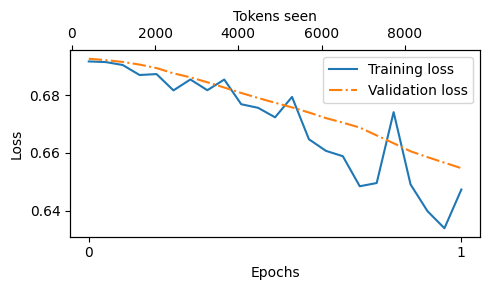

In [57]:
epochs_tensor = torch.linspace(0, epochs, len(result["train_loss"]))
plot_losses(
    epochs_seen=epochs_tensor,
    tokens_seen=result["tokens_seen_track"],
    train_losses=result["train_loss"],
    val_losses=result["val_loss"]
)

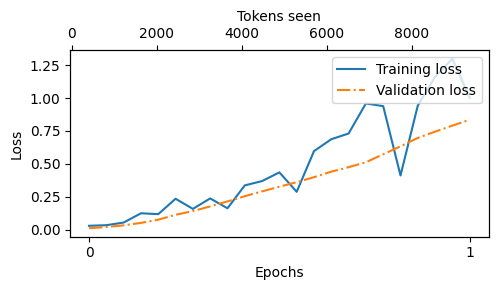

In [58]:
train_reward_margins = [i-j for i,j in zip(result["train_chosen_reward"], result["train_rejected_reward"])]
val_reward_margins = [i-j for i,j in zip(result["val_chosen_reward"], result["val_rejected_reward"])]

plot_losses(
    epochs_seen=epochs_tensor,
    tokens_seen=result["tokens_seen_track"],
    train_losses=train_reward_margins,
    val_losses=val_reward_margins
)

In [56]:
#lets test the fine-tuned model on test data
for entry in test_data[:3]:
  formatted_entry = format_entry(entry)
  output_tokens_policy = generate(
      model=policy_model,
      inp_tokens=text_to_token_ids(formatted_entry, tokenizer).to(device),
      context_size=BASE_CONFIG['context_length'],
      max_tokens=256,
      eos_id=50256
  )
  output_tokens_ref = generate(
      model=ref_model,
      inp_tokens=text_to_token_ids(formatted_entry, tokenizer).to(device),
      context_size=BASE_CONFIG['context_length'],
      max_tokens=256,
      eos_id=50256
  )
  output_text_policy = token_ids_to_text(output_tokens_policy, tokenizer)
  output_text_ref = token_ids_to_text(output_tokens_ref, tokenizer)
  response_text_policy = output_text_policy[len(formatted_entry):].replace("### Response:",'').strip()
  response_text_ref = output_text_ref[len(formatted_entry):].replace("### Response:",'').strip()
  print(formatted_entry)
  print(f"Correct Response: {entry['output']}")
  print(f'Policy Model Response: {response_text_policy}')
  print(f'Reference Model Response: {response_text_ref}\n\n\n')


Below is the instruction that describes a task. Write an appropriate response to address the instruction. 

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.
Correct Response: The car is as fast as lightning.
Policy Model Response: The car would be 'very' fast.
Reference Model Response: The car is as fast as a cheetah.



Below is the instruction that describes a task. Write an appropriate response to address the instruction. 

### Instruction:
What type of cloud is typically associated with thunderstorms?
Correct Response: The type of cloud typically associated with thunderstorms is cumulonimbus.
Policy Model Response: The type of cloud typically associated with thunderstorms is a cumulus.
Reference Model Response: A thunderstorm is a type of cumulus cloud that is formed when thunderstorms produce a dense, fast-moving, and intense updraft of air.



Below is the instruction that describes a task. Write an appropriate response to address the instru